In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import ListedColormap

In [2]:
# Set device
device='cpu'
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
np.random.seed(42)

Using device: cpu


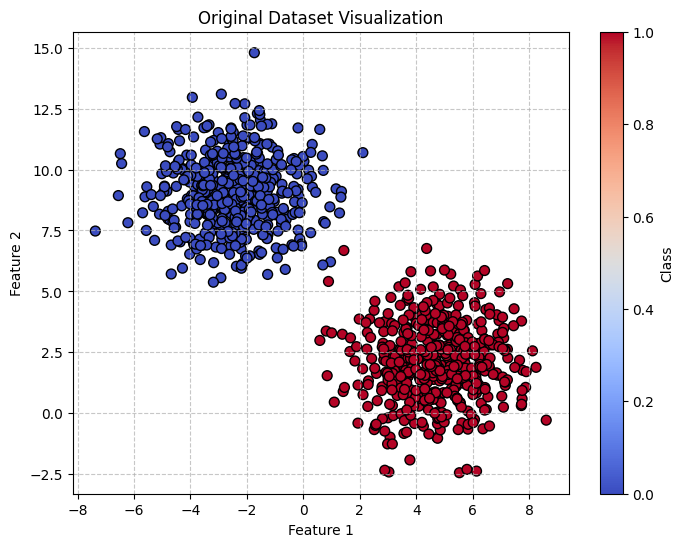

In [3]:
# Generate synthetic dataset with 2 classes and 2 dimensional feature space
X, y = make_blobs(n_samples=1000, centers=2, n_features=2,
                  cluster_std=1.5, random_state=42)

# Visualize the original dataset
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm,
            edgecolors='k', marker='o', s=50)
plt.title('Original Dataset Visualization')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Class')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [4]:
# Split the data (70% train, 10% validation, 20% test)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.125, random_state=42)  # 0.125*0.8=0.1

# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

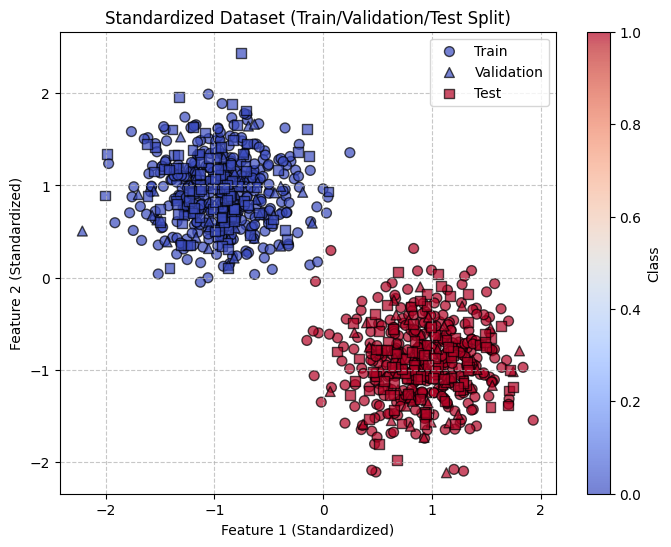

In [5]:
# Visualize the standardized dataset
plt.figure(figsize=(8, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.coolwarm,
            edgecolors='k', marker='o', s=50, label='Train', alpha=0.7)
plt.scatter(X_val[:, 0], X_val[:, 1], c=y_val, cmap=plt.cm.coolwarm,
            edgecolors='k', marker='^', s=50, label='Validation', alpha=0.7) # Added validation set
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.coolwarm,
            edgecolors='k', marker='s', s=50, label='Test', alpha=0.7)
plt.title('Standardized Dataset (Train/Validation/Test Split)') # Updated title
plt.xlabel('Feature 1 (Standardized)')
plt.ylabel('Feature 2 (Standardized)')
plt.colorbar(label='Class')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [6]:
# Convert to PyTorch tensors and move to device
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)
X_val_tensor = torch.FloatTensor(X_val).to(device) # Added validation tensor
y_val_tensor = torch.LongTensor(y_val).to(device)   # Added validation tensor
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)

In [7]:
# Define the linear classifier model
class LinearClassifier(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LinearClassifier, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        return self.linear(x)

In [8]:
def train_model(loss_function, X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor, 
                input_dim=2, output_dim=2, learning_rate=0.01, epochs=1000):
    # Initialize model and move to device
    model = LinearClassifier(input_dim=input_dim, output_dim=output_dim).to(device)

    # Define optimizer
    optimizer = optim.SGD(model.parameters(), lr=learning_rate)

    # Lists to store losses and accuracies
    losses = []
    accuracies = []
    val_losses = []
    val_accuracies = []

    # Training loop
    for epoch in range(epochs):
        # Forward pass
        model.train()  # Set model to training mode
        outputs = model(X_train_tensor)

        # Compute loss
        if loss_function == 'mse':
            # For MSE, we need to convert labels to one-hot encoding
            y_one_hot = torch.zeros(y_train_tensor.size(0), output_dim).to(device)
            y_one_hot.scatter_(1, y_train_tensor.unsqueeze(1), 1)
            loss = nn.MSELoss()(outputs, y_one_hot)
        else:
            loss = nn.CrossEntropyLoss()(outputs, y_train_tensor)

        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Calculate training accuracy
        _, predicted = torch.max(outputs.data, 1)
        accuracy = (predicted == y_train_tensor).sum().item() / y_train_tensor.size(0)

        # Evaluate on validation set
        model.eval() # Set model to evaluation mode
        with torch.no_grad():
            val_outputs = model(X_val_tensor)
            if loss_function == 'mse':
                 # For MSE, we need to convert labels to one-hot encoding
                y_val_one_hot = torch.zeros(y_val_tensor.size(0), output_dim).to(device)
                y_val_one_hot.scatter_(1, y_val_tensor.unsqueeze(1), 1)
                val_loss = nn.MSELoss()(val_outputs, y_val_one_hot)
            else:
                val_loss = nn.CrossEntropyLoss()(val_outputs, y_val_tensor)
            _, val_predicted = torch.max(val_outputs.data, 1)
            val_accuracy = (val_predicted == y_val_tensor).sum().item() / y_val_tensor.size(0)

        # Store metrics
        losses.append(loss.item())
        accuracies.append(accuracy)
        val_losses.append(val_loss.item())
        val_accuracies.append(val_accuracy)

        # Print every 100 epochs
        if (epoch+1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {loss.item():.4f}, Train Accuracy: {accuracy:.4f}, Val Loss: {val_loss.item():.4f}, Val Accuracy: {val_accuracy:.4f}')

    return model, losses, accuracies, val_losses, val_accuracies

In [9]:
print("Training with Cross-Entropy Loss:")
ce_model, ce_losses, ce_accuracies, ce_val_losses, ce_val_accuracies = train_model(
    'ce', X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor)

Training with Cross-Entropy Loss:
Epoch [100/1000], Train Loss: 0.3753, Train Accuracy: 0.9900, Val Loss: 0.3727, Val Accuracy: 1.0000
Epoch [200/1000], Train Loss: 0.2088, Train Accuracy: 0.9986, Val Loss: 0.2048, Val Accuracy: 1.0000
Epoch [300/1000], Train Loss: 0.1460, Train Accuracy: 0.9986, Val Loss: 0.1415, Val Accuracy: 1.0000
Epoch [400/1000], Train Loss: 0.1136, Train Accuracy: 0.9986, Val Loss: 0.1089, Val Accuracy: 1.0000
Epoch [500/1000], Train Loss: 0.0938, Train Accuracy: 0.9986, Val Loss: 0.0890, Val Accuracy: 1.0000
Epoch [600/1000], Train Loss: 0.0804, Train Accuracy: 0.9986, Val Loss: 0.0756, Val Accuracy: 1.0000
Epoch [700/1000], Train Loss: 0.0708, Train Accuracy: 0.9986, Val Loss: 0.0660, Val Accuracy: 1.0000
Epoch [800/1000], Train Loss: 0.0634, Train Accuracy: 0.9986, Val Loss: 0.0587, Val Accuracy: 1.0000
Epoch [900/1000], Train Loss: 0.0577, Train Accuracy: 0.9986, Val Loss: 0.0529, Val Accuracy: 1.0000
Epoch [1000/1000], Train Loss: 0.0530, Train Accuracy: 0.

In [10]:
# Train with MSE loss functions
print("\nTraining with MSE Loss:")
mse_model, mse_losses, mse_accuracies, mse_val_losses, mse_val_accuracies = train_model(
    'mse', X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor)


Training with MSE Loss:
Epoch [100/1000], Train Loss: 0.0369, Train Accuracy: 0.9971, Val Loss: 0.0316, Val Accuracy: 1.0000
Epoch [200/1000], Train Loss: 0.0223, Train Accuracy: 0.9971, Val Loss: 0.0194, Val Accuracy: 1.0000
Epoch [300/1000], Train Loss: 0.0209, Train Accuracy: 0.9971, Val Loss: 0.0188, Val Accuracy: 1.0000
Epoch [400/1000], Train Loss: 0.0207, Train Accuracy: 0.9971, Val Loss: 0.0189, Val Accuracy: 1.0000
Epoch [500/1000], Train Loss: 0.0206, Train Accuracy: 0.9971, Val Loss: 0.0189, Val Accuracy: 1.0000
Epoch [600/1000], Train Loss: 0.0206, Train Accuracy: 0.9971, Val Loss: 0.0189, Val Accuracy: 1.0000
Epoch [700/1000], Train Loss: 0.0205, Train Accuracy: 0.9971, Val Loss: 0.0189, Val Accuracy: 1.0000
Epoch [800/1000], Train Loss: 0.0205, Train Accuracy: 0.9971, Val Loss: 0.0189, Val Accuracy: 1.0000
Epoch [900/1000], Train Loss: 0.0205, Train Accuracy: 0.9971, Val Loss: 0.0189, Val Accuracy: 1.0000
Epoch [1000/1000], Train Loss: 0.0205, Train Accuracy: 0.9971, Val

In [11]:
# Move models to CPU for plotting if they were on GPU
if torch.cuda.is_available():
    ce_model = ce_model.cpu()
    mse_model = mse_model.cpu()

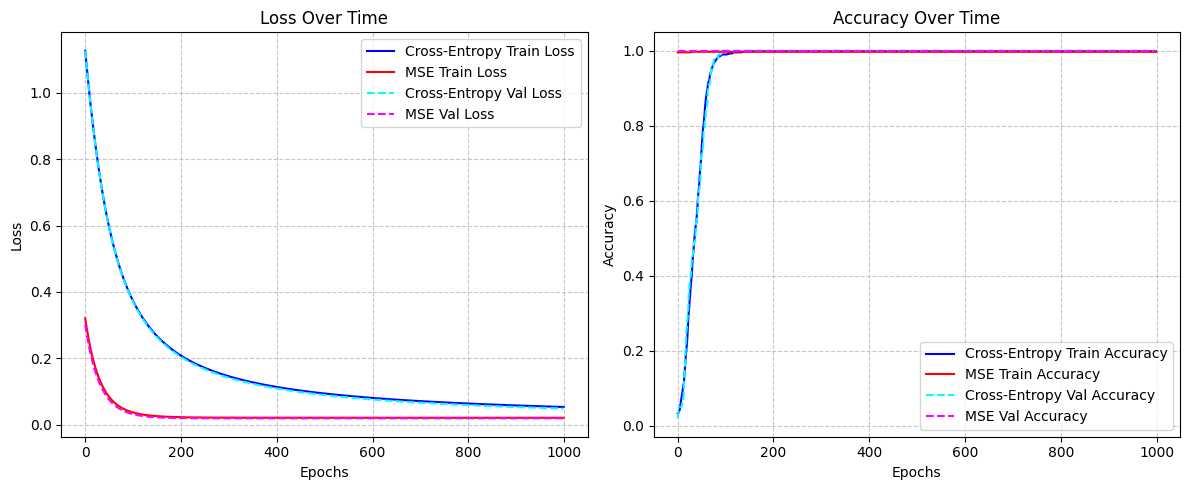

In [12]:
# Plotting training results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(ce_losses, label='Cross-Entropy Train Loss', color='blue')
plt.plot(mse_losses, label='MSE Train Loss', color='red')
plt.plot(ce_val_losses, label='Cross-Entropy Val Loss', color='cyan', linestyle='--') # Added CE validation loss
plt.plot(mse_val_losses, label='MSE Val Loss', color='magenta', linestyle='--') # Added MSE validation loss
plt.title('Loss Over Time') # Updated title
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.plot(ce_accuracies, label='Cross-Entropy Train Accuracy', color='blue')
plt.plot(mse_accuracies, label='MSE Train Accuracy', color='red')
plt.plot(ce_val_accuracies, label='Cross-Entropy Val Accuracy', color='cyan', linestyle='--') # Added CE validation accuracy
plt.plot(mse_val_accuracies, label='MSE Val Accuracy', color='magenta', linestyle='--') # Added MSE validation accuracy
plt.title('Accuracy Over Time') # Updated title
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [13]:
# Evaluate on test set
def evaluate_model(model, X_test_tensor, y_test_tensor):
    model.eval()
    # Move model to device
    model = model.to(device)
    with torch.no_grad():
        outputs = model(X_test_tensor)
        _, predicted = torch.max(outputs.data, 1)
        accuracy = (predicted == y_test_tensor).sum().item() / y_test_tensor.size(0)
    return accuracy

ce_test_accuracy = evaluate_model(ce_model, X_test_tensor, y_test_tensor)
mse_test_accuracy = evaluate_model(mse_model, X_test_tensor, y_test_tensor)

print(f"\nTest Accuracy - Cross-Entropy: {ce_test_accuracy:.4f}")
print(f"Test Accuracy - MSE: {mse_test_accuracy:.4f}")


Test Accuracy - Cross-Entropy: 1.0000
Test Accuracy - MSE: 1.0000


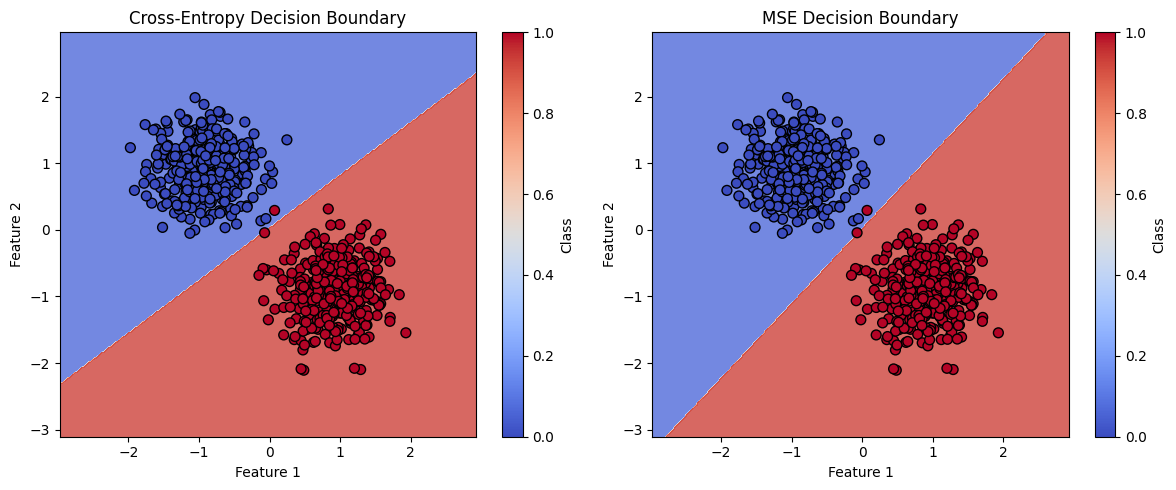

In [14]:
# Function to plot decision boundaries
def plot_decision_boundary(model, X, y, title):
    # Set min and max values and give it some padding
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    h = 0.02  # step size in the mesh

    # Generate a grid of points with distance h between them
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Predict the function value for the whole grid
    Z = model(torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()]))
    _, Z = torch.max(Z.data, 1)
    Z = Z.numpy().reshape(xx.shape)

    # Plot the contour and training examples
    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm,
                edgecolors='k', s=50)
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.colorbar(label='Class')

# Plot decision boundaries
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_decision_boundary(ce_model, X_train, y_train, "Cross-Entropy Decision Boundary")

plt.subplot(1, 2, 2)
plot_decision_boundary(mse_model, X_train, y_train, "MSE Decision Boundary")

plt.tight_layout()
plt.show()

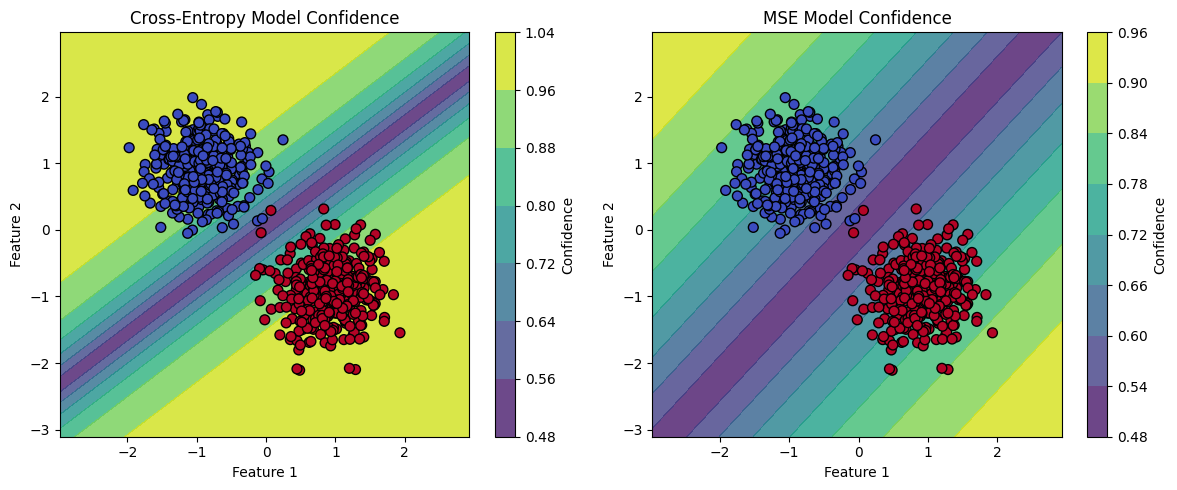

In [15]:
# Additional visualization: Model confidence
def plot_model_confidence(model, X, y, title):
    # Set min and max values and give it some padding
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    h = 0.02  # step size in the mesh

    # Generate a grid of points with distance h between them
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Predict the function value for the whole grid
    Z = model(torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()]))
    # Apply softmax to get probabilities
    softmax = nn.Softmax(dim=1)
    Z_probs = softmax(Z)
    # Get the confidence (max probability)
    confidence, _ = torch.max(Z_probs.data, 1)
    confidence = confidence.numpy().reshape(xx.shape)

    # Plot the confidence
    plt.contourf(xx, yy, confidence, cmap=plt.cm.viridis, alpha=0.8)
    plt.colorbar(label='Confidence')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm,
                edgecolors='k', s=50)
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')

# Plot model confidence
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_model_confidence(ce_model, X_train, y_train, "Cross-Entropy Model Confidence")

plt.subplot(1, 2, 2)
plot_model_confidence(mse_model, X_train, y_train, "MSE Model Confidence")

plt.tight_layout()
plt.show()

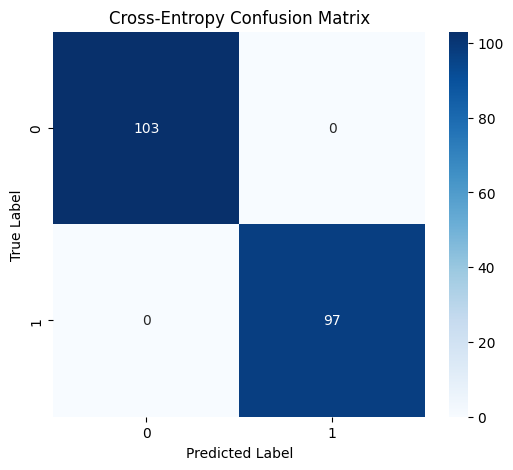

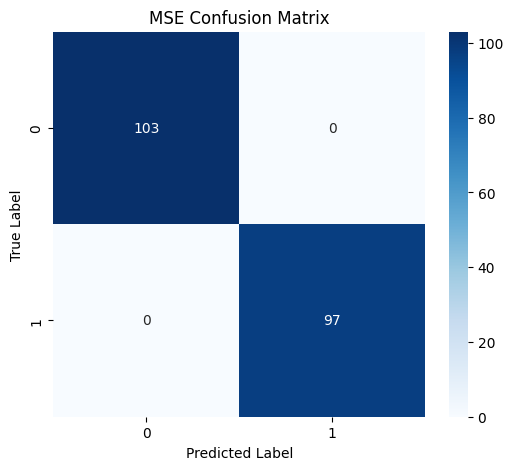

In [16]:
# Confusion matrix visualization
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(model, X_test_tensor, y_test, title):
    model.eval()
    with torch.no_grad():
        outputs = model(X_test_tensor)
        _, predicted = torch.max(outputs.data, 1)

    cm = confusion_matrix(y_test, predicted.numpy())
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')

# Plot confusion matrices
plot_confusion_matrix(ce_model, X_test_tensor, y_test, "Cross-Entropy Confusion Matrix")
plt.show()

plot_confusion_matrix(mse_model, X_test_tensor, y_test, "MSE Confusion Matrix")
plt.show()

In [17]:
def swapper(new_std, centers=2, n_features=2, input_dim=None):
    if input_dim is None:
        input_dim = n_features
    
    # Determine output dimension based on number of centers
    output_dim = centers
    
    print(f"\n{'='*60}")
    print(f"EXPERIMENT: std={new_std}, centers={centers}, features={n_features}")
    print(f"{'='*60}")
    
    # Generate synthetic dataset
    X, y = make_blobs(n_samples=1000, centers=centers, n_features=n_features,
                    cluster_std=new_std, random_state=42)

    # Visualize the original dataset (only for 2D)
    if n_features == 2:
        plt.figure(figsize=(8, 6))
        plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.tab10,
                    edgecolors='k', marker='o', s=50)
        plt.title(f'Original Dataset: std={new_std}, centers={centers}, features={n_features}')
        plt.xlabel('Feature 1')
        plt.ylabel('Feature 2')
        plt.colorbar(label='Class')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.show()

    # Split the data (70% train, 10% validation, 20% test)
    X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.125, random_state=42)

    # Standardize the data
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    # Visualize the standardized dataset (only for 2D)
    if n_features == 2:
        plt.figure(figsize=(8, 6))
        plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.tab10,
                    edgecolors='k', marker='o', s=50, label='Train', alpha=0.7)
        plt.scatter(X_val[:, 0], X_val[:, 1], c=y_val, cmap=plt.cm.tab10,
                    edgecolors='k', marker='^', s=50, label='Validation', alpha=0.7)
        plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.tab10,
                    edgecolors='k', marker='s', s=50, label='Test', alpha=0.7)
        plt.title(f'Standardized Dataset: std={new_std}, centers={centers}, features={n_features}')
        plt.xlabel('Feature 1 (Standardized)')
        plt.ylabel('Feature 2 (Standardized)')
        plt.colorbar(label='Class')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.show()

    # Convert to PyTorch tensors and move to device
    X_train_tensor = torch.FloatTensor(X_train).to(device)
    y_train_tensor = torch.LongTensor(y_train).to(device)
    X_val_tensor = torch.FloatTensor(X_val).to(device)
    y_val_tensor = torch.LongTensor(y_val).to(device)
    X_test_tensor = torch.FloatTensor(X_test).to(device)
    y_test_tensor = torch.LongTensor(y_test).to(device)

    # Train with CE loss functions
    print("Training with Cross-Entropy Loss:")
    ce_model, ce_losses, ce_accuracies, ce_val_losses, ce_val_accuracies = train_model(
        'ce', X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor, 
        input_dim=input_dim, output_dim=output_dim)

    # Train with MSE loss functions
    print("\nTraining with MSE Loss:")
    mse_model, mse_losses, mse_accuracies, mse_val_losses, mse_val_accuracies = train_model(
        'mse', X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor, 
        input_dim=input_dim, output_dim=output_dim)

    # Plotting training results
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(ce_losses, label='Cross-Entropy Train Loss', color='blue')
    plt.plot(mse_losses, label='MSE Train Loss', color='red')
    plt.plot(ce_val_losses, label='Cross-Entropy Val Loss', color='cyan', linestyle='--')
    plt.plot(mse_val_losses, label='MSE Val Loss', color='magenta', linestyle='--')
    plt.title(f'Loss Over Time: std={new_std}, centers={centers}, features={n_features}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.subplot(1, 2, 2)
    plt.plot(ce_accuracies, label='Cross-Entropy Train Accuracy', color='blue')
    plt.plot(mse_accuracies, label='MSE Train Accuracy', color='red')
    plt.plot(ce_val_accuracies, label='Cross-Entropy Val Accuracy', color='cyan', linestyle='--')
    plt.plot(mse_val_accuracies, label='MSE Val Accuracy', color='magenta', linestyle='--')
    plt.title(f'Accuracy Over Time: std={new_std}, centers={centers}, features={n_features}')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

    # Evaluate on test set
    ce_test_accuracy = evaluate_model(ce_model, X_test_tensor, y_test_tensor)
    mse_test_accuracy = evaluate_model(mse_model, X_test_tensor, y_test_tensor)

    print(f"\nTest Accuracy - Cross-Entropy: {ce_test_accuracy:.4f}")
    print(f"Test Accuracy - MSE: {mse_test_accuracy:.4f}")

    # Plot decision boundaries (only for 2D)
    if n_features == 2:
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plot_decision_boundary(ce_model, X_train, y_train, "Cross-Entropy Decision Boundary")

        plt.subplot(1, 2, 2)
        plot_decision_boundary(mse_model, X_train, y_train, "MSE Decision Boundary")

        plt.tight_layout()
        plt.show()

        # Plot model confidence (only for 2D)
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plot_model_confidence(ce_model, X_train, y_train, "Cross-Entropy Model Confidence")

        plt.subplot(1, 2, 2)
        plot_model_confidence(mse_model, X_train, y_train, "MSE Model Confidence")

        plt.tight_layout()
        plt.show()

    # Plot confusion matrices
    plot_confusion_matrix(ce_model, X_test_tensor, y_test, "Cross-Entropy Confusion Matrix")
    plt.show()

    plot_confusion_matrix(mse_model, X_test_tensor, y_test, "MSE Confusion Matrix")
    plt.show()
    
    return ce_model, mse_model, ce_test_accuracy, mse_test_accuracy

#Q1) Increase Std to 3.0 in "make_blob" function and report all the plots and measures  [2 Marks]


EXPERIMENT: std=3.0, centers=2, features=2


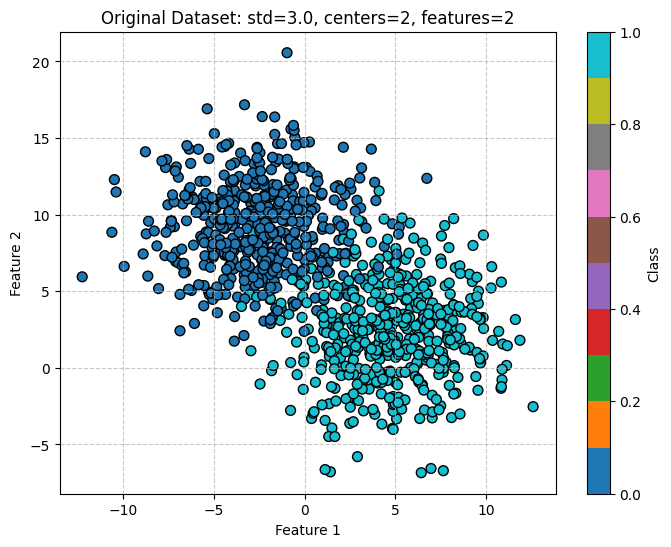

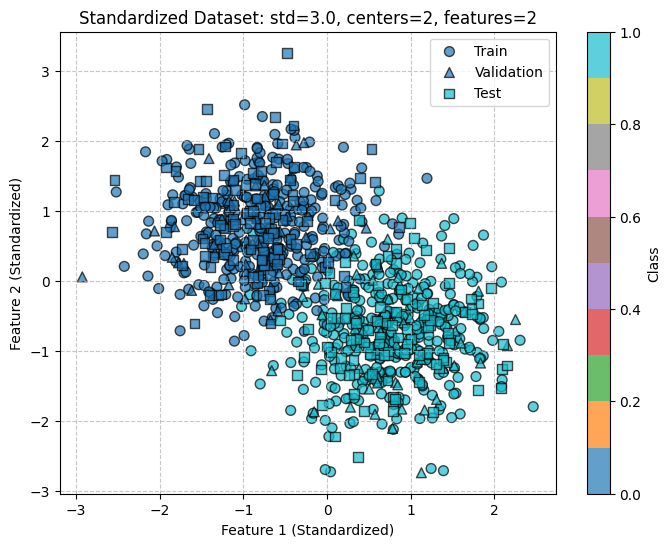

Training with Cross-Entropy Loss:
Epoch [100/1000], Train Loss: 0.4004, Train Accuracy: 0.9200, Val Loss: 0.3831, Val Accuracy: 0.9400
Epoch [200/1000], Train Loss: 0.2984, Train Accuracy: 0.9457, Val Loss: 0.2804, Val Accuracy: 0.9300
Epoch [300/1000], Train Loss: 0.2516, Train Accuracy: 0.9500, Val Loss: 0.2334, Val Accuracy: 0.9400
Epoch [400/1000], Train Loss: 0.2248, Train Accuracy: 0.9486, Val Loss: 0.2064, Val Accuracy: 0.9400
Epoch [500/1000], Train Loss: 0.2075, Train Accuracy: 0.9500, Val Loss: 0.1888, Val Accuracy: 0.9500
Epoch [600/1000], Train Loss: 0.1954, Train Accuracy: 0.9500, Val Loss: 0.1763, Val Accuracy: 0.9500
Epoch [700/1000], Train Loss: 0.1865, Train Accuracy: 0.9500, Val Loss: 0.1669, Val Accuracy: 0.9500
Epoch [800/1000], Train Loss: 0.1796, Train Accuracy: 0.9500, Val Loss: 0.1596, Val Accuracy: 0.9500
Epoch [900/1000], Train Loss: 0.1741, Train Accuracy: 0.9500, Val Loss: 0.1538, Val Accuracy: 0.9500
Epoch [1000/1000], Train Loss: 0.1697, Train Accuracy: 0.

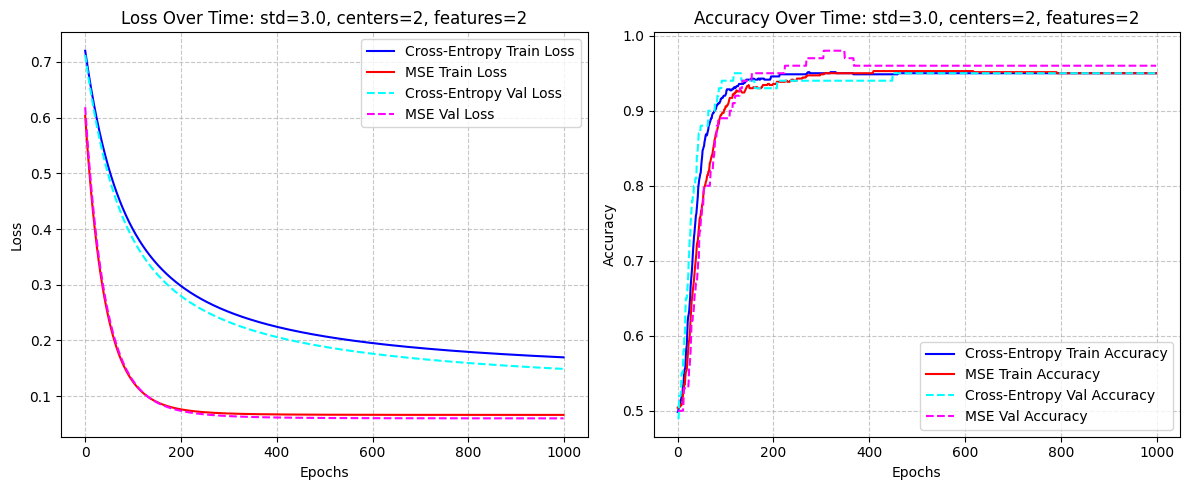


Test Accuracy - Cross-Entropy: 0.9550
Test Accuracy - MSE: 0.9600


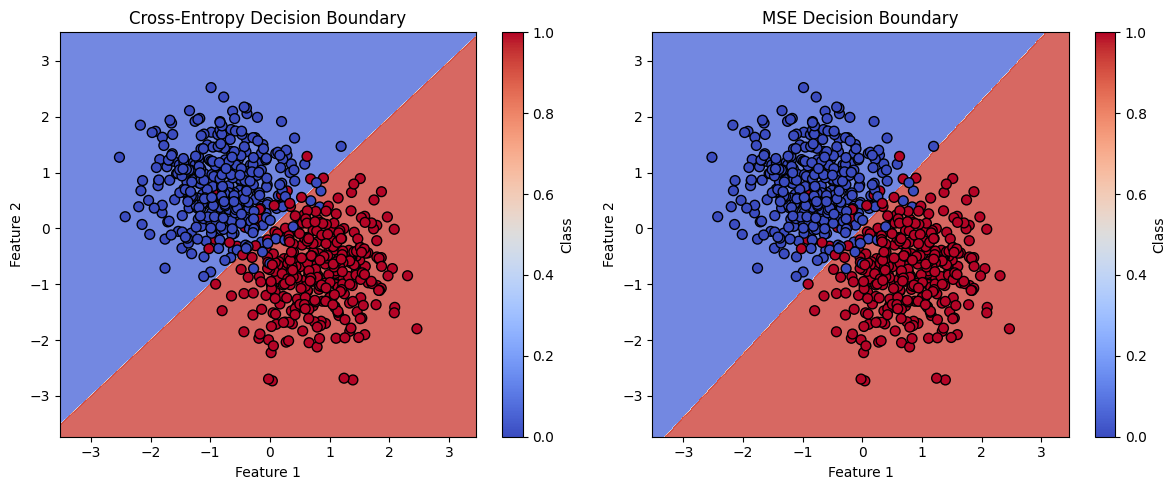

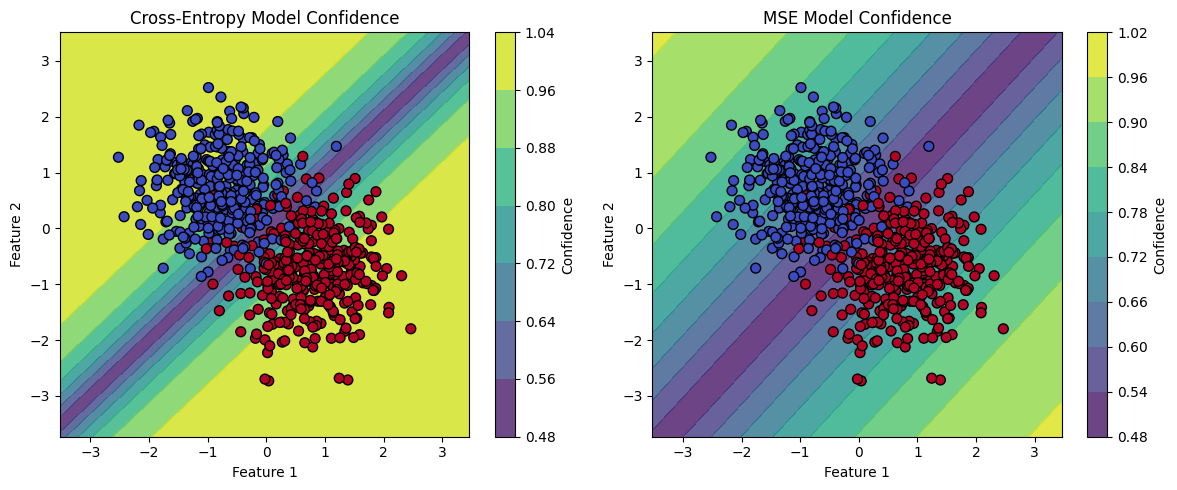

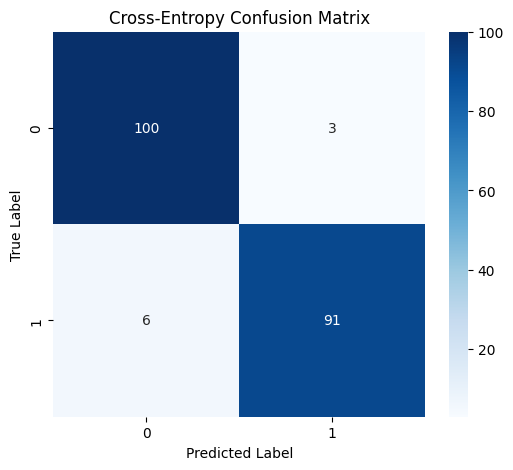

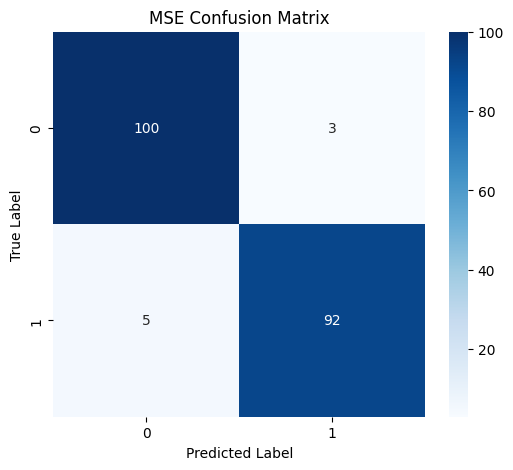

In [18]:
ce_model_q1, mse_model_q1, ce_acc_q1, mse_acc_q1 = swapper(3.0)

#Q2) Increase n_cluster=5 and std=3.0 in "make_blob" function and report all the plots and measures [3 Marks]


EXPERIMENT: std=3.0, centers=5, features=2


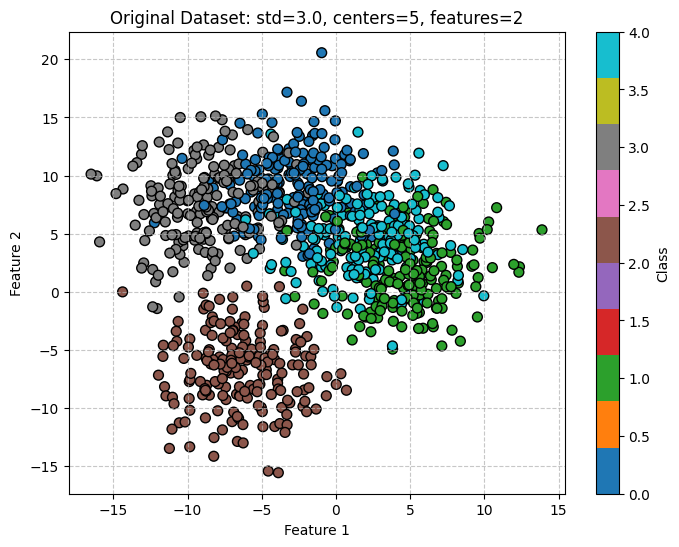

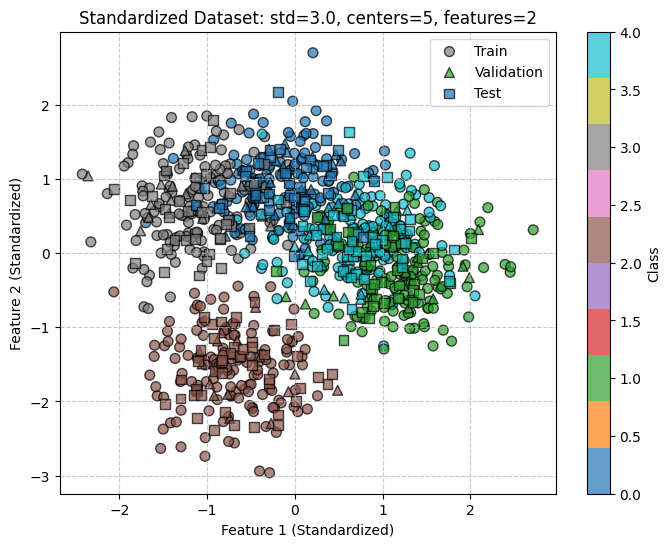

Training with Cross-Entropy Loss:
Epoch [100/1000], Train Loss: 1.4732, Train Accuracy: 0.2971, Val Loss: 1.5369, Val Accuracy: 0.2600
Epoch [200/1000], Train Loss: 1.2730, Train Accuracy: 0.4814, Val Loss: 1.3470, Val Accuracy: 0.3800
Epoch [300/1000], Train Loss: 1.1405, Train Accuracy: 0.5843, Val Loss: 1.2173, Val Accuracy: 0.5000
Epoch [400/1000], Train Loss: 1.0482, Train Accuracy: 0.6371, Val Loss: 1.1242, Val Accuracy: 0.5400
Epoch [500/1000], Train Loss: 0.9806, Train Accuracy: 0.6529, Val Loss: 1.0541, Val Accuracy: 0.5600
Epoch [600/1000], Train Loss: 0.9290, Train Accuracy: 0.6557, Val Loss: 0.9992, Val Accuracy: 0.5800
Epoch [700/1000], Train Loss: 0.8882, Train Accuracy: 0.6700, Val Loss: 0.9549, Val Accuracy: 0.6400
Epoch [800/1000], Train Loss: 0.8550, Train Accuracy: 0.6914, Val Loss: 0.9182, Val Accuracy: 0.6600
Epoch [900/1000], Train Loss: 0.8274, Train Accuracy: 0.7057, Val Loss: 0.8873, Val Accuracy: 0.6900
Epoch [1000/1000], Train Loss: 0.8040, Train Accuracy: 0.

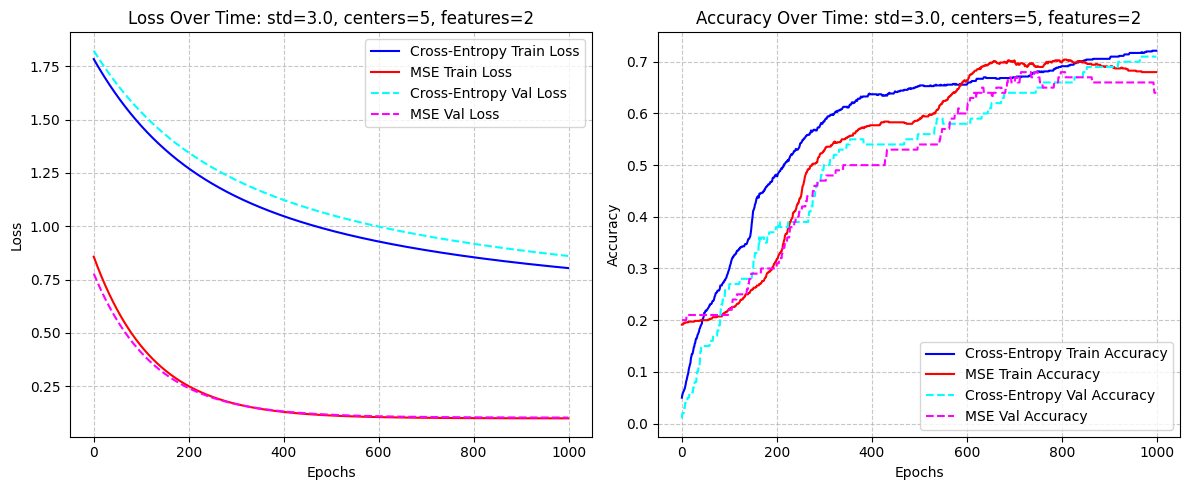


Test Accuracy - Cross-Entropy: 0.6950
Test Accuracy - MSE: 0.6550


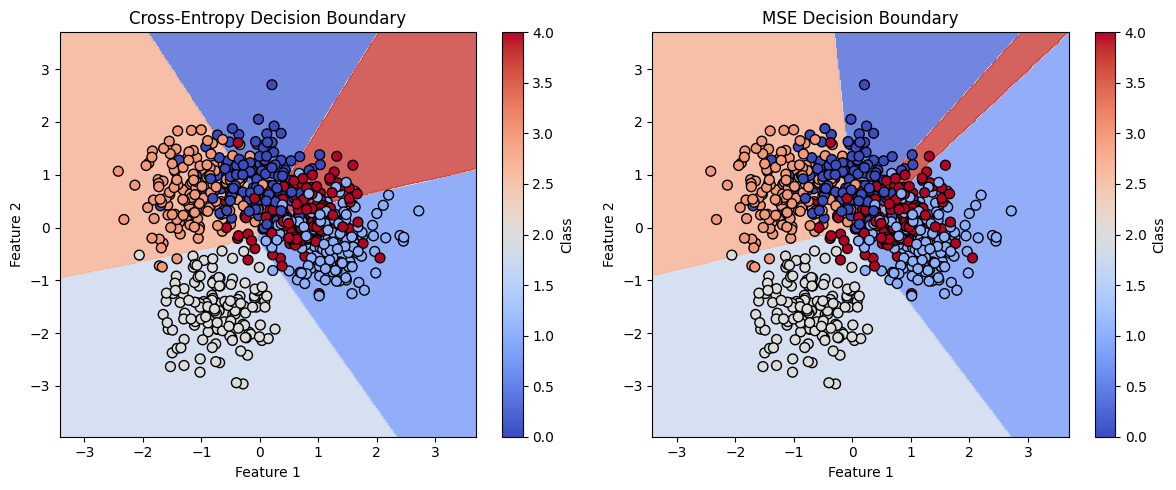

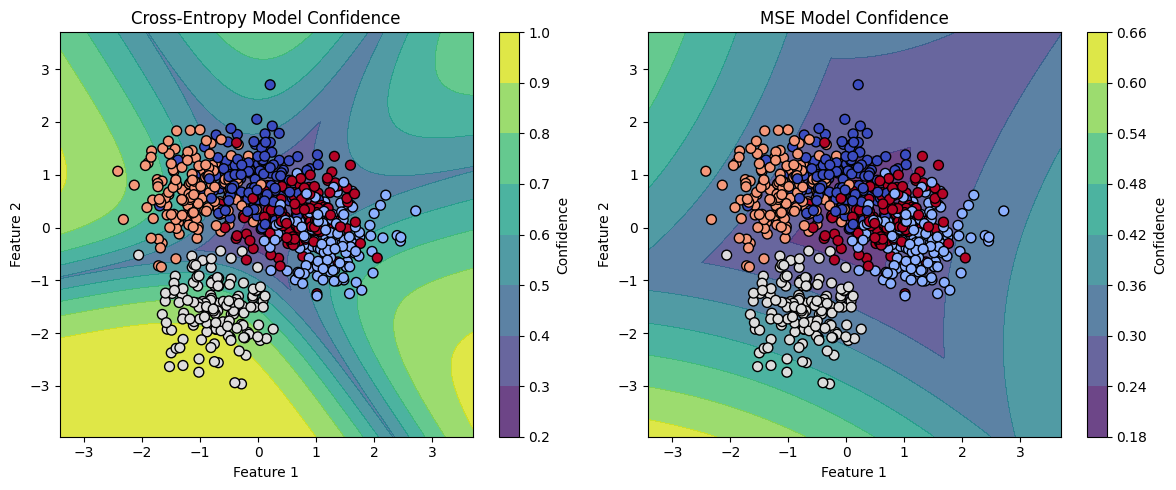

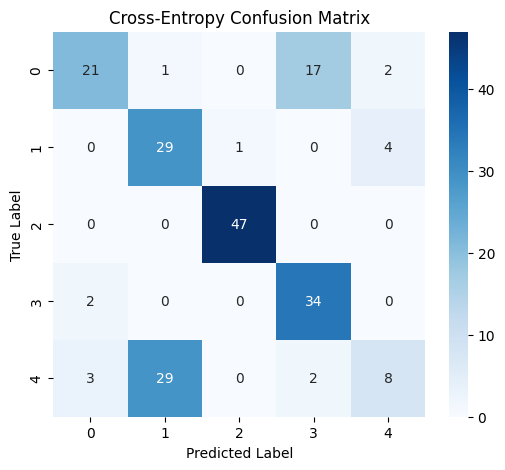

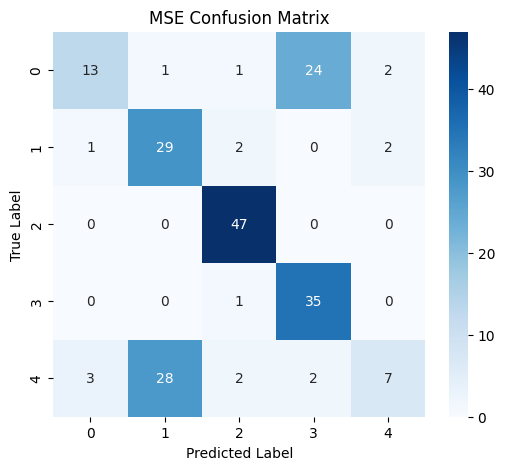

In [19]:
ce_model_q2, mse_model_q2, ce_acc_q2, mse_acc_q2 = swapper(new_std=3.0, centers=5)

#Q3) Perform simiar experiment with 20 dimensional features(using make_blob) with 5 clusters and std=3.0 and report all measures (train-val-test accuracies, accuracy curves, confusion matrix) for both CE and MSE loss [5 Marks]


EXPERIMENT: std=3.0, centers=5, features=20
Training with Cross-Entropy Loss:
Epoch [100/1000], Train Loss: 0.4045, Train Accuracy: 0.9971, Val Loss: 0.3859, Val Accuracy: 0.9800
Epoch [200/1000], Train Loss: 0.2019, Train Accuracy: 1.0000, Val Loss: 0.1939, Val Accuracy: 1.0000
Epoch [300/1000], Train Loss: 0.1334, Train Accuracy: 1.0000, Val Loss: 0.1294, Val Accuracy: 1.0000
Epoch [400/1000], Train Loss: 0.0997, Train Accuracy: 1.0000, Val Loss: 0.0977, Val Accuracy: 1.0000
Epoch [500/1000], Train Loss: 0.0798, Train Accuracy: 1.0000, Val Loss: 0.0789, Val Accuracy: 1.0000
Epoch [600/1000], Train Loss: 0.0666, Train Accuracy: 1.0000, Val Loss: 0.0664, Val Accuracy: 1.0000
Epoch [700/1000], Train Loss: 0.0573, Train Accuracy: 1.0000, Val Loss: 0.0575, Val Accuracy: 1.0000
Epoch [800/1000], Train Loss: 0.0503, Train Accuracy: 1.0000, Val Loss: 0.0509, Val Accuracy: 1.0000
Epoch [900/1000], Train Loss: 0.0449, Train Accuracy: 1.0000, Val Loss: 0.0457, Val Accuracy: 1.0000
Epoch [1000/

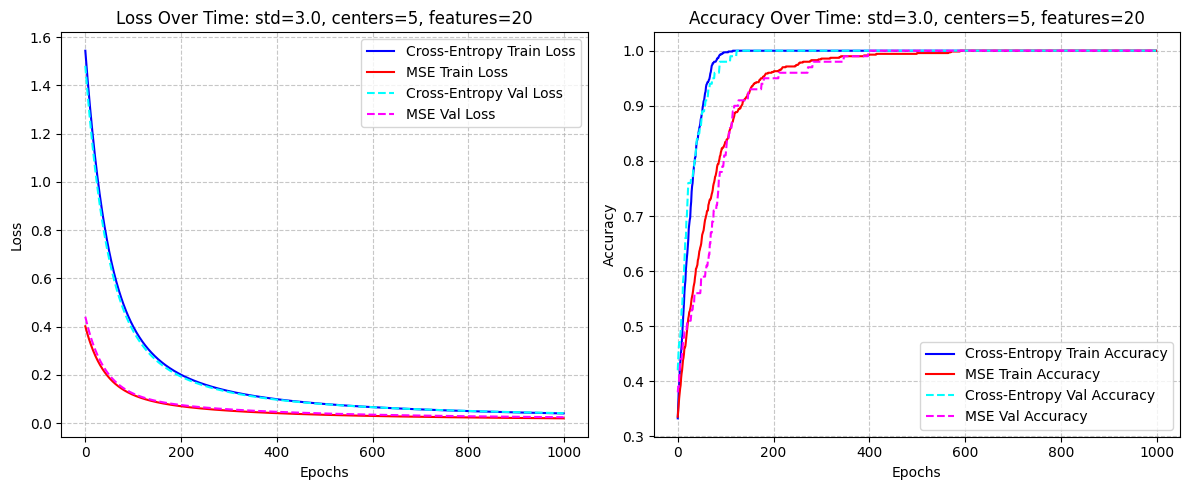


Test Accuracy - Cross-Entropy: 1.0000
Test Accuracy - MSE: 1.0000


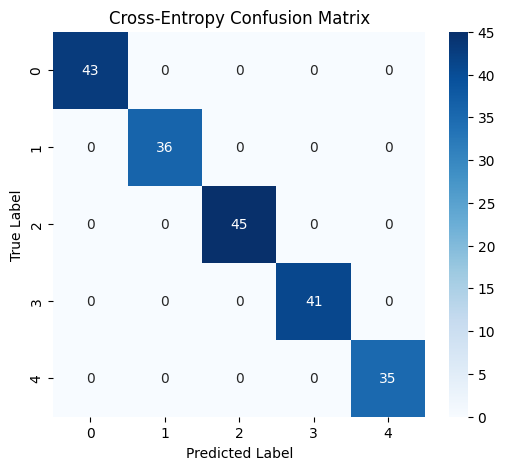

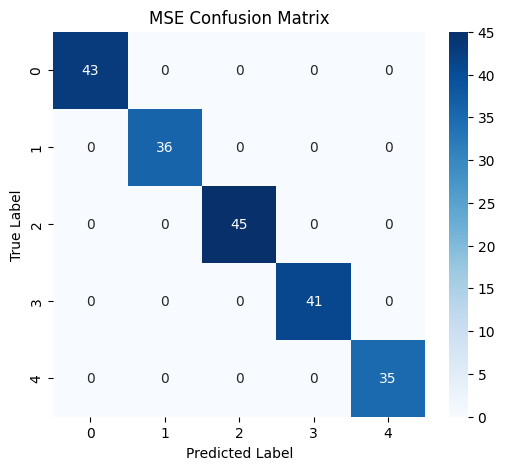

In [20]:
ce_model_q3, mse_model_q3, ce_acc_q3, mse_acc_q3 = swapper(new_std=3.0, centers=5, n_features=20)